In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
df=pd.read_csv('/content/goalkeepers_dataset (1).csv')
df

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage,transfer_risk_level
0,Alisson Becker,31.0,Brazil,Liverpool,91.0,91,42M,3.0,7,26,114,15,38,75.0,High
1,Thibaut Courtois,32.0,Belgium,Real Madrid,75.0,91,40M,4.0,6,31,69,10,16,81.2,High
2,Gianluigi Donnarumma,25.0,Italy,PSG,88.0,89,80M,1.0,3,31,88,15,42,67.7,High
3,Manuel Neuer,38.0,Germany,Bayern Munich,88.0,88,2M,3.0,6,39,103,13,17,85.8,High
4,Marc-André ter Stegen,31.0,Germany,Barcelona,88.0,90,26M,3.0,7,37,43,13,28,60.6,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,Lars Diallo,26.0,Turkey,Leicester City,69.0,69,13M,5.0,2,25,55,13,32,63.2,High
1496,Son Laurent,29.0,Norway,Flamengo,81.0,81,28M,0.0,4,21,62,21,39,61.4,High
1497,Jean Mensah,19.0,Argentina,Real Madrid,73.0,73,13M,0.0,0,28,100,4,42,70.4,High
1498,Sven Brown,26.0,Australia,Aston Villa,71.0,72,3M,3.0,0,17,116,15,33,77.9,High


In [ ]:
df.shape


(1500, 15)

In [ ]:
df.head()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage,transfer_risk_level
0,Alisson Becker,31.0,Brazil,Liverpool,91.0,91,42M,3.0,7,26,114,15,38,75.0,High
1,Thibaut Courtois,32.0,Belgium,Real Madrid,75.0,91,40M,4.0,6,31,69,10,16,81.2,High
2,Gianluigi Donnarumma,25.0,Italy,PSG,88.0,89,80M,1.0,3,31,88,15,42,67.7,High
3,Manuel Neuer,38.0,Germany,Bayern Munich,88.0,88,2M,3.0,6,39,103,13,17,85.8,High
4,Marc-André ter Stegen,31.0,Germany,Barcelona,88.0,90,26M,3.0,7,37,43,13,28,60.6,High


In [ ]:
df.tail()

,player_name,age,nationality,club,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage,transfer_risk_level
1495,Lars Diallo,26.0,Turkey,Leicester City,69.0,69,13M,5.0,2,25,55,13,32,63.2,High
1496,Son Laurent,29.0,Norway,Flamengo,81.0,81,28M,0.0,4,21,62,21,39,61.4,High
1497,Jean Mensah,19.0,Argentina,Real Madrid,73.0,73,13M,0.0,0,28,100,4,42,70.4,High
1498,Sven Brown,26.0,Australia,Aston Villa,71.0,72,3M,3.0,0,17,116,15,33,77.9,High
1499,Matthew Keita,28.0,Uruguay,Sevilla,65.0,65,6M,4.0,7,38,129,4,15,89.6,High


In [ ]:
df.dtypes

,0
player_name,object
age,float64
nationality,object
club,object
overall_rating,float64
potential_rating,int64
market_value_million_eur,object
contract_years_left,float64
injury_history,int64
matches_played,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   player_name               1500 non-null   object 
 1   age                       1455 non-null   float64
 2   nationality               1500 non-null   object 
 3   club                      1500 non-null   object 
 4   overall_rating            1460 non-null   float64
 5   potential_rating          1500 non-null   int64  
 6   market_value_million_eur  1500 non-null   object 
 7   contract_years_left       1450 non-null   float64
 8   injury_history            1500 non-null   int64  
 9   matches_played            1500 non-null   int64  
 10  saves                     1500 non-null   int64  
 11  clean_sheets              1500 non-null   int64  
 12  goals_conceded            1500 non-null   int64  
 13  save_percentage           1500 non-null   float64
 14  transfer

In [ ]:
df.describe()

,age,overall_rating,potential_rating,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage
count,1455.000000,1460.000000,1500.000000,1450.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,26.314777,74.699315,76.483333,2.633793,3.254000,24.745333,78.488000,11.524667,32.359333,69.534133
std,3.408848,6.457909,7.964757,1.474547,2.214367,8.676943,29.289118,5.828783,12.635901,12.413438
min,18.000000,62.000000,62.000000,0.000000,0.000000,10.000000,30.000000,2.000000,10.000000,36.500000
25%,25.000000,71.000000,70.000000,2.000000,1.000000,17.000000,52.750000,6.000000,22.000000,61.375000
50%,26.000000,75.000000,76.000000,3.000000,3.000000,25.000000,78.000000,11.000000,32.000000,70.600000
75%,28.000000,78.000000,83.000000,3.000000,5.000000,32.000000,104.000000,17.000000,43.000000,78.800000
max,40.000000,91.000000,94.000000,5.000000,8.000000,39.000000,129.000000,21.000000,54.000000,92.600000


In [ ]:
df.isna().sum()

,0
player_name,0
age,45
nationality,0
club,0
overall_rating,40
potential_rating,0
market_value_million_eur,0
contract_years_left,50
injury_history,0
matches_played,0


In [ ]:
df1=df['nationality'].value_counts()

Text(0.5, 1.0, 'Nations')

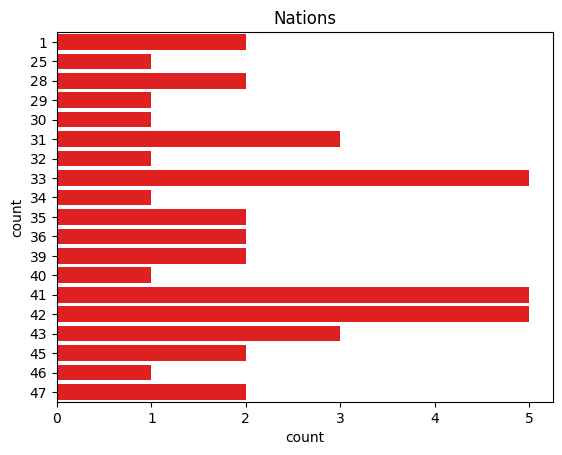

In [ ]:
sns.countplot(y=df1,data=df,color='r')
plt.title('Nations')

In [ ]:
df2=df['club'].value_counts()

Text(0.5, 1.0, 'clubs')

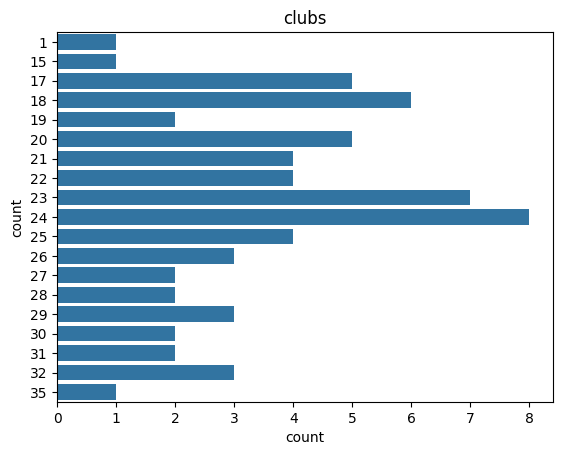

In [ ]:
sns.countplot(y=df2,data=df)
plt.title('clubs')

In [ ]:
df['market_value_million_eur'] = df['market_value_million_eur'].str.replace('M','').astype(float)

Text(0.5, 1.0, 'Transfer value')

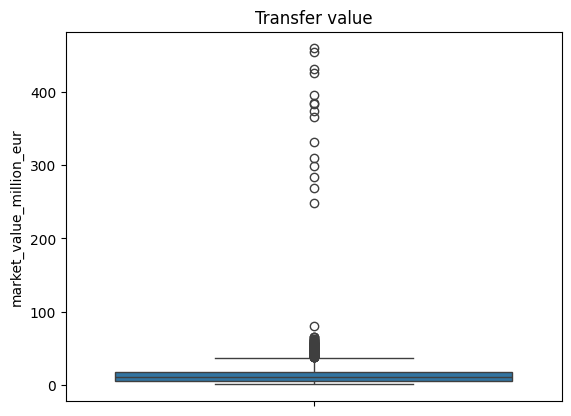

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
Q1=df['market_value_million_eur'].quantile(0.25)
Q3=df['market_value_million_eur'].quantile(0.75)
IQR=Q3-Q1
lower_fence=Q1-1.5*IQR
upper_fence=Q3+1.5*IQR

In [ ]:
print(lower_fence,upper_fence)

-14.5 37.5


In [ ]:
df['market_value_million_eur']=df['market_value_million_eur'].clip(lower=lower_fence,upper=upper_fence)

Text(0.5, 1.0, 'Transfer value')

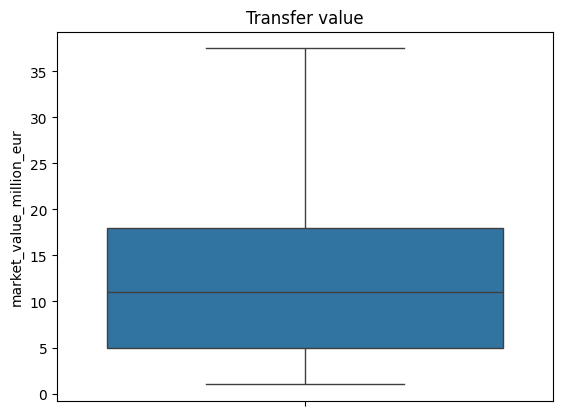

In [ ]:
sns.boxplot(y=df['market_value_million_eur'],data=df)
plt.title('Transfer value')

In [ ]:
df['age'].unique()

array([31., 32., 25., 38., 28., 30., 27., 35., 29., 26., 34., 24., 23.,
       22., 21., nan, 18., 33., 20., 19., 40., 36., 39., 37.])

In [ ]:
df['contract_years_left'].unique()

array([ 3.,  4.,  1.,  0.,  5.,  2., nan])

In [ ]:
df['overall_rating'].unique()

array([91., 75., 88., 85., 83., 64., 63., nan, 62., 66., 84., 80., 87.,
       68., 65., 79., 81., 86., 78., 69., 71., 67., 74., 72., 76., 73.,
       82., 70., 77.])

In [ ]:
df['age']=df['age'].fillna(df['age']).median()
df['contract_years_left']=df['contract_years_left'].fillna(df['contract_years_left']).median()
df['overall_rating']=df['overall_rating'].fillna(df['overall_rating']).median()

In [ ]:
df.isna().sum()

,0
player_name,0
age,0
nationality,0
club,0
overall_rating,0
potential_rating,0
market_value_million_eur,0
contract_years_left,0
injury_history,0
matches_played,0


In [ ]:
df_gd=pd.get_dummies(df[['nationality','club']],drop_first=True,dtype=int)
df_gd

,nationality_Argentina,nationality_Australia,nationality_Belgium,nationality_Brazil,nationality_Cameroon,nationality_Canada,nationality_Chile,nationality_Colombia,nationality_Croatia,nationality_Czech Republic,...,club_River Plate,club_Sevilla,club_Sporting CP,club_Stuttgart,club_Torino,club_Tottenham,club_Valencia,club_Villarreal,club_West Ham,club_Wolves
0,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1495,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1496,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1497,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1498,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df = df.drop(columns=['nationality', 'club', 'player_name'])


In [ ]:
df

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage,transfer_risk_level
0,26.0,75.0,91,37.5,3.0,7,26,114,15,38,75.0,High
1,26.0,75.0,91,37.5,3.0,6,31,69,10,16,81.2,High
2,26.0,75.0,89,37.5,3.0,3,31,88,15,42,67.7,High
3,26.0,75.0,88,2.0,3.0,6,39,103,13,17,85.8,High
4,26.0,75.0,90,26.0,3.0,7,37,43,13,28,60.6,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,26.0,75.0,69,13.0,3.0,2,25,55,13,32,63.2,High
1496,26.0,75.0,81,28.0,3.0,4,21,62,21,39,61.4,High
1497,26.0,75.0,73,13.0,3.0,0,28,100,4,42,70.4,High
1498,26.0,75.0,72,3.0,3.0,0,17,116,15,33,77.9,High


In [ ]:
df_con=df.copy()

In [ ]:
df_con

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage,transfer_risk_level
0,26.0,75.0,91,37.5,3.0,7,26,114,15,38,75.0,High
1,26.0,75.0,91,37.5,3.0,6,31,69,10,16,81.2,High
2,26.0,75.0,89,37.5,3.0,3,31,88,15,42,67.7,High
3,26.0,75.0,88,2.0,3.0,6,39,103,13,17,85.8,High
4,26.0,75.0,90,26.0,3.0,7,37,43,13,28,60.6,High
...,...,...,...,...,...,...,...,...,...,...,...,...
1495,26.0,75.0,69,13.0,3.0,2,25,55,13,32,63.2,High
1496,26.0,75.0,81,28.0,3.0,4,21,62,21,39,61.4,High
1497,26.0,75.0,73,13.0,3.0,0,28,100,4,42,70.4,High
1498,26.0,75.0,72,3.0,3.0,0,17,116,15,33,77.9,High


In [ ]:
from sklearn.preprocessing import LabelEncoder
le_target = LabelEncoder()
df['transfer_risk_level'] = le_target.fit_transform(df['transfer_risk_level'])

In [ ]:
x=df_con.drop(columns='transfer_risk_level')


In [ ]:
x

,age,overall_rating,potential_rating,market_value_million_eur,contract_years_left,injury_history,matches_played,saves,clean_sheets,goals_conceded,save_percentage
0,26.0,75.0,91,37.5,3.0,7,26,114,15,38,75.0
1,26.0,75.0,91,37.5,3.0,6,31,69,10,16,81.2
2,26.0,75.0,89,37.5,3.0,3,31,88,15,42,67.7
3,26.0,75.0,88,2.0,3.0,6,39,103,13,17,85.8
4,26.0,75.0,90,26.0,3.0,7,37,43,13,28,60.6
...,...,...,...,...,...,...,...,...,...,...,...
1495,26.0,75.0,69,13.0,3.0,2,25,55,13,32,63.2
1496,26.0,75.0,81,28.0,3.0,4,21,62,21,39,61.4
1497,26.0,75.0,73,13.0,3.0,0,28,100,4,42,70.4
1498,26.0,75.0,72,3.0,3.0,0,17,116,15,33,77.9


In [ ]:
y=df_con['transfer_risk_level']

In [ ]:
y

,transfer_risk_level
0,High
1,High
2,High
3,High
4,High
...,...
1495,High
1496,High
1497,High
1498,High


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(1200, 11)

In [ ]:
x_test.shape

(300, 11)

In [ ]:
y_train.shape

(1200,)

In [ ]:
y_test.shape

(300,)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler  = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test  = scaler.transform(x_test)
x_train

array([[ 0.        ,  0.        ,  1.21138321, ...,  0.94452342,
        -1.36931044,  0.74429   ],
       [ 0.        ,  0.        , -1.69517827, ..., -1.64163745,
         0.92927638, -0.6381303 ],
       [ 0.        ,  0.        , -0.43145588, ..., -0.6071731 ,
         0.13666023,  0.41475958],
       ...,
       [ 0.        ,  0.        , -0.93694484, ..., -1.46922673,
         0.77075315,  0.31831165],
       [ 0.        ,  0.        , -0.05233917, ..., -1.46922673,
         0.29518346,  0.67195406],
       [ 0.        ,  0.        ,  0.32677755, ..., -0.26235165,
         0.05739862, -0.91943676]])

In [ ]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(random_state=42)
x_train_res, y_train_res = smt.fit_resample(x_train, y_train)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(x_train_res,y_train_res)
y_pred=model.predict(x_test)


In [ ]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)

In [ ]:
score

0.9166666666666666

              precision    recall  f1-score   support

        High       0.91      0.99      0.95       223
         Low       0.95      0.71      0.81        77

    accuracy                           0.92       300
   macro avg       0.93      0.85      0.88       300
weighted avg       0.92      0.92      0.91       300



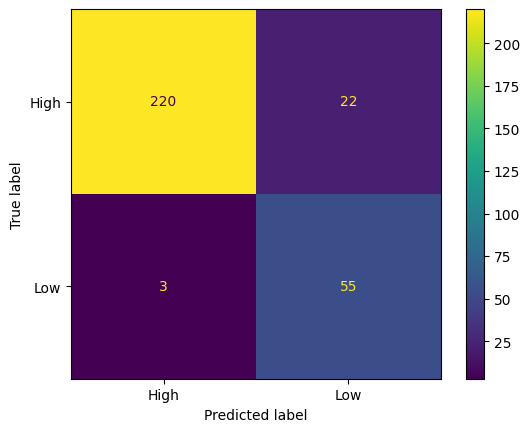

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print(classification_report(y_pred, y_test, target_names=['High','Low']))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['High','Low'])
plt.show()

In [ ]:
joblib.dump(model,'model_gk.pkl')
joblib.dump(scaler,'scaler_gk.pkl')
joblib.dump(le_target,'encoder_gk.pkl')

['encoder_gk.pkl']

In [ ]:
from google.colab import files
files.download('model_gk.pkl')
files.download('scaler_gk.pkl')
files.download('encoder_gk.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>